In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
df = pd.read_csv("../data/raw/fraud.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

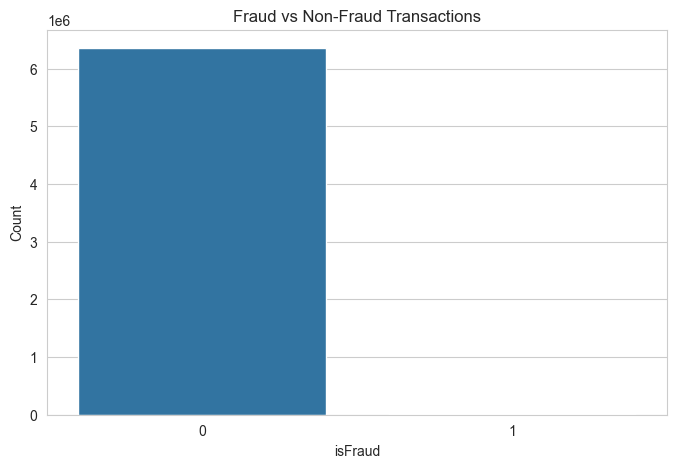

Fraud Percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [8]:
fraud_counts = df["isFraud"].value_counts()

plt.figure()
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.show()

print("Fraud Percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)

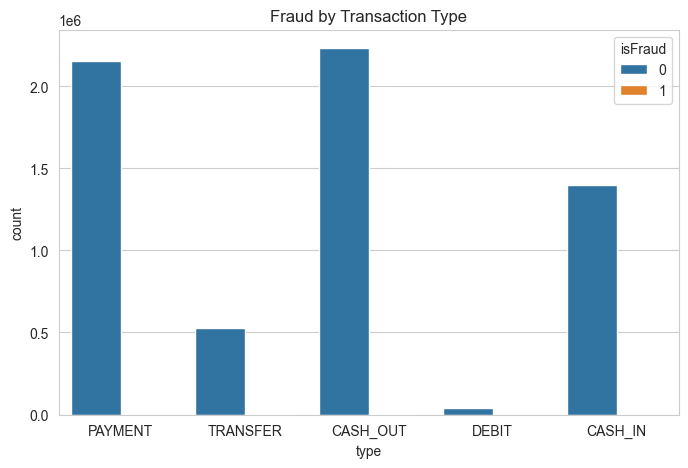

In [9]:
plt.figure()
sns.countplot(data=df, x="type", hue="isFraud")
plt.title("Fraud by Transaction Type")
plt.show()

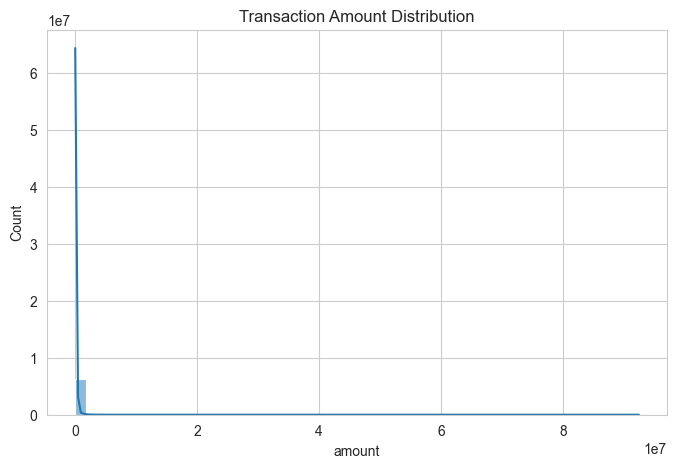

In [10]:
plt.figure()
sns.histplot(df["amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

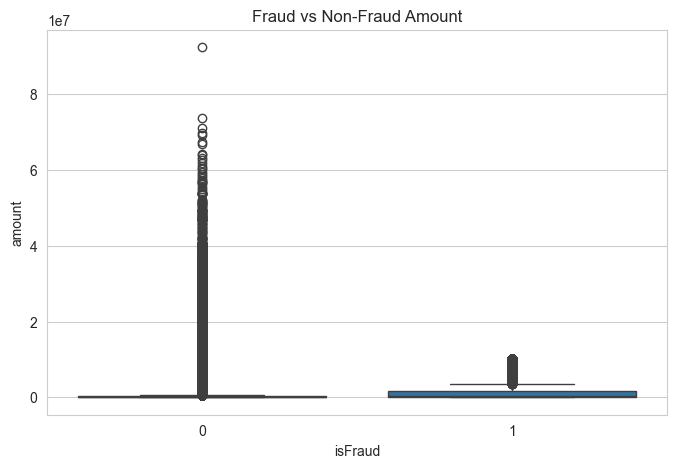

In [11]:
plt.figure()
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Fraud vs Non-Fraud Amount")
plt.show()

In [12]:
df["balance_diff_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balance_diff_dest"] = df["newbalanceDest"] - df["oldbalanceDest"]

df[["balance_diff_orig", "balance_diff_dest"]].head()

,balance_diff_orig,balance_diff_dest
0,9839.64,0.0
1,1864.28,0.0
2,181.00,0.0
3,181.00,-21182.0
4,11668.14,0.0


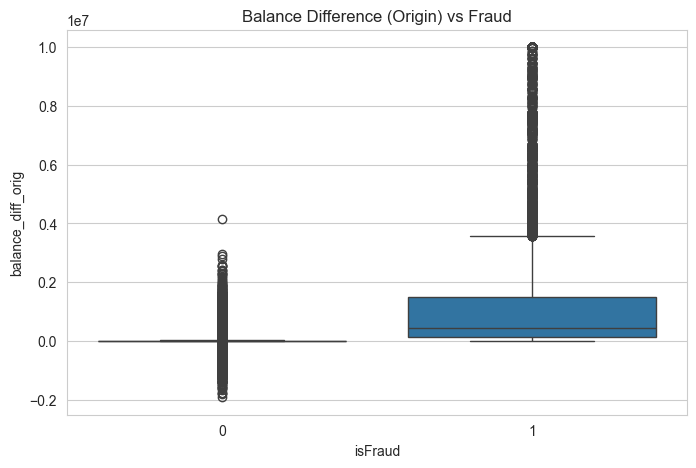

In [13]:
plt.figure()
sns.boxplot(x="isFraud", y="balance_diff_orig", data=df)
plt.title("Balance Difference (Origin) vs Fraud")
plt.show()

In [14]:
pd.crosstab(df["isFraud"], df["isFlaggedFraud"])

isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


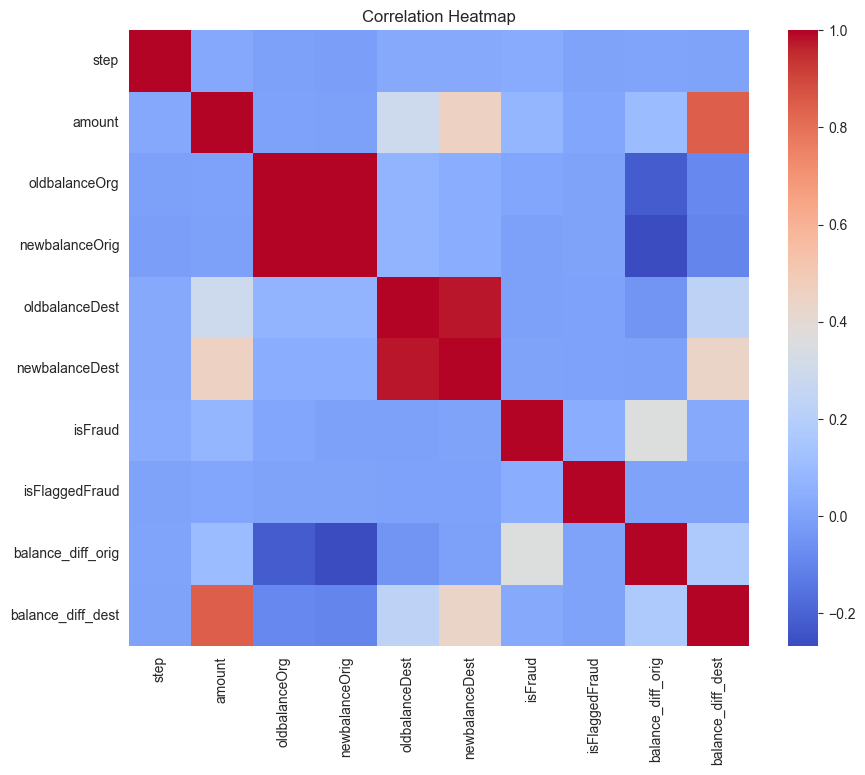

In [15]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
fraud_rate = df.groupby("type")["isFraud"].mean() * 100
fraud_rate

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

In [17]:
zero_balance_fraud = df[
    (df["oldbalanceOrg"] == 0) &
    (df["amount"] > 0) &
    (df["isFraud"] == 1)
]

zero_balance_fraud.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest
724,1,CASH_OUT,416001.33,C749981943,0.0,0.0,C667346055,102.00,9291619.62,1,0,0.0,9291517.62
14861,8,CASH_OUT,181728.11,C2102265902,0.0,0.0,C789014007,11397.00,184477.77,1,0,0.0,173080.77
25875,8,TRANSFER,1078013.76,C1026280121,0.0,0.0,C277510102,0.00,970749.68,1,0,0.0,970749.68
77745,10,CASH_OUT,277970.88,C489647033,0.0,0.0,C571514738,0.00,277970.88,1,0,0.0,277970.88
138559,11,TRANSFER,1933920.80,C1706582969,0.0,0.0,C461905695,1283762.85,3217683.65,1,0,0.0,1933920.80


## Key Insights

1. Dataset is highly imbalanced ( approx 0.1% fraud).
2. Most fraud occurs in TRANSFER and CASH_OUT.
3. Fraud transactions often show abnormal balance differences.
4. Rule-based flag (isFlaggedFraud) captures very few fraud cases.
5. Feature engineering on balance differences can improve detection.

These insights guide model building and threshold tuning.